In [48]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Dataset
from sklearn.metrics import *
from sklearn.model_selection import train_test_split
import seaborn as sns
from glob import glob
from skimage.io import imread
import warnings

warnings.filterwarnings('ignore')

print("All modules have been imported (PyTorch version)")


All modules have been imported (PyTorch version)


In [49]:
import pandas as pd

trainLabels = pd.read_csv("./trainLabels.csv")
trainLabels

,image,level
0,10_left,0
1,10_right,0
2,13_left,0
3,13_right,0
4,15_left,1
...,...,...
35121,44347_right,0
35122,44348_left,0
35123,44348_right,0
35124,44349_left,0


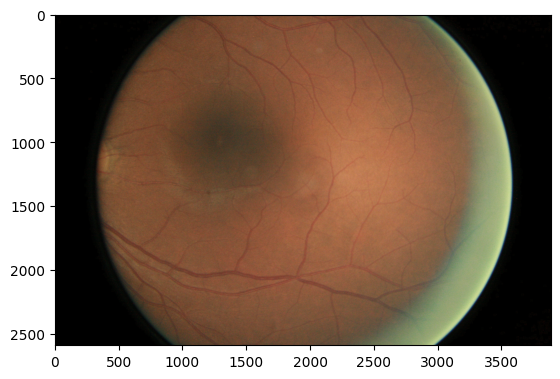

In [50]:
from PIL import Image

img = Image.open("../../../Downloads/train/1116_right.jpeg")

import matplotlib.pyplot as plt

plt.imshow(img)

In [51]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline

In [52]:
import os
base_image_dir = os.path.join('.', '../../../Downloads/train/')
df = pd.read_csv(os.path.join('./trainLabels.csv'))
df['path'] = df['image'].map(lambda x: os.path.join(base_image_dir,'{}.jpeg'.format(x)))
df['exists'] = df['path'].map(os.path.exists) #Most of the files do not exist because this is a sample of the original dataset
df = df[df['exists']]
df = df.drop(columns=['image','exists'])
df = df.sample(frac=1).reset_index(drop=True)#shuffle dataframe
df['level'] = df['level'].astype(str)
df

,level,path
0,0,.\../../../Downloads/train/28246_left.jpeg
1,0,.\../../../Downloads/train/6639_left.jpeg
2,4,.\../../../Downloads/train/20574_left.jpeg
3,3,.\../../../Downloads/train/27224_left.jpeg
4,0,.\../../../Downloads/train/42206_right.jpeg
...,...,...
35121,4,.\../../../Downloads/train/19600_left.jpeg
35122,2,.\../../../Downloads/train/31226_right.jpeg
35123,0,.\../../../Downloads/train/6148_left.jpeg
35124,0,.\../../../Downloads/train/38356_left.jpeg


<Axes: >

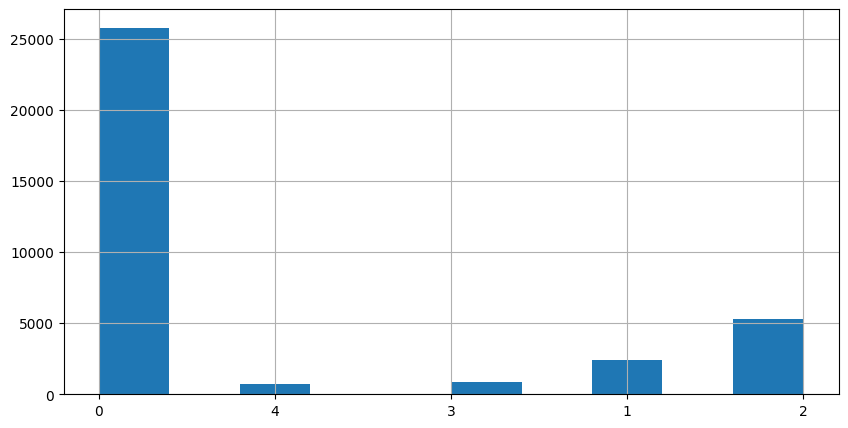

In [53]:
df['level'].hist(figsize = (10, 5))

In [54]:
def balance_data(class_size,df):
    train_df = df.groupby(['level']).apply(lambda x: x.sample(class_size, replace = True)).reset_index(drop = True)
    train_df = train_df.sample(frac=1).reset_index(drop=True)
    print('New Data Size:', train_df.shape[0], 'Old Size:', df.shape[0])
    train_df['level'].hist(figsize = (10, 5))
    return train_df


7026

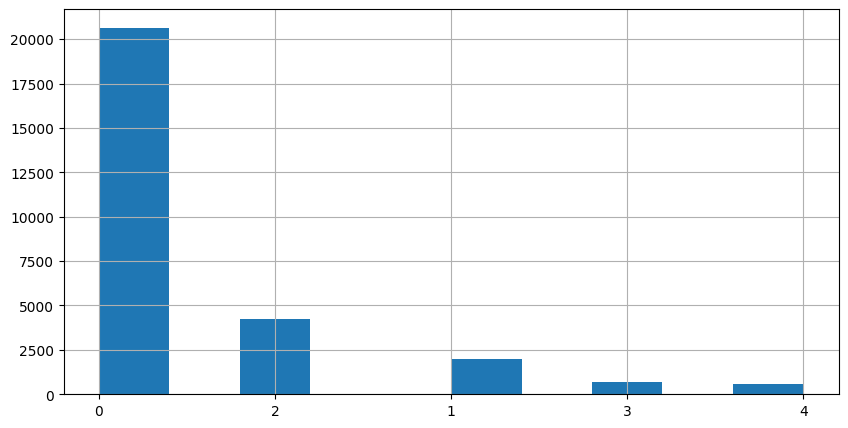

In [55]:
from sklearn.model_selection import train_test_split
train_df, val_df = train_test_split(df,test_size=0.2) 
train_df['level'].hist(figsize = (10, 5))
len(val_df)

New Data Size: 103240 Old Size: 28100


<Axes: >

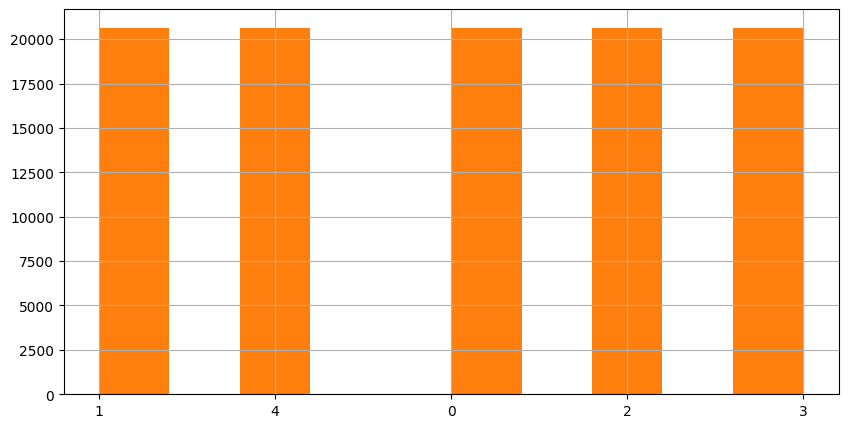

In [56]:
train_df = balance_data(train_df.pivot_table(index='level', aggfunc=len).max().max(),train_df) # I will oversample such that all classes have the same number of images as the maximum
train_df['level'].hist(figsize = (10, 5))

In [57]:
df = pd.concat([train_df,val_df]) #beginning of this dataframe is the oversampled training set, end is the validation set
len(df)

110266

In [58]:
from torchvision import transforms

# Define transformations for training and testing data
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize images to a fixed size
    transforms.RandomHorizontalFlip(),  # Apply horizontal flip
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),  # Simulate zooming
    transforms.ToTensor(),  # Convert to tensor
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])  # Normalize pixel values
])

test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize images
    transforms.ToTensor(),  # Convert to tensor
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])  # Normalize
])

print("Data augmentation and preprocessing pipeline updated for PyTorch!")


Data augmentation and preprocessing pipeline updated for PyTorch!


In [59]:
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import pandas as pd
import os

class CustomDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = os.path.join(".", self.dataframe.iloc[idx]["path"])  # Path to image
        image = Image.open(img_path).convert("RGB")  # Open image and convert to RGB
        label = self.dataframe.iloc[idx]["level"]  # Get label

        if self.transform:
            image = self.transform(image)  # Apply transformations

        return image, label

# Create dataset instances
train_dataset = CustomDataset(train_df, transform=train_transforms)
test_dataset = CustomDataset(val_df, transform=test_transforms)

# Create DataLoader instances
# DataLoader optimizations (ensure pin_memory is enabled)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=0)
val_loader = DataLoader(test_dataset, batch_size=128, shuffle=False, num_workers=0)

print("PyTorch DataLoaders are ready!")


PyTorch DataLoaders are ready!


In [60]:
import itertools
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    plt.figure(figsize = (6,6))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=90)
    plt.yticks(tick_marks, classes)
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    thresh = cm.max() / 2.
    cm = np.round(cm,2)
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j],
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")
    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()

In [61]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()
        
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.conv5 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.conv6 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.conv7 = nn.Conv2d(256, 256, kernel_size=3, padding=1)
        self.conv8 = nn.Conv2d(256, 128, kernel_size=3, padding=1)
        self.conv9 = nn.Conv2d(128, 128, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout = nn.Dropout(0.25)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool(x)
        x = self.dropout(x)

        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        x = self.pool(x)
        x = self.dropout(x)

        x = F.relu(self.conv4(x))
        x = F.relu(self.conv5(x))
        x = self.pool(x)
        x = self.dropout(x)

        x = F.relu(self.conv6(x))
        x = F.relu(self.conv7(x))
        x = self.pool(x)
        x = self.dropout(x)

        x = F.relu(self.conv8(x))
        x = F.relu(self.conv9(x))
        x = self.pool(x)
        x = self.dropout(x)

        return x

# Instantiate the model
model = CNNModel()
print(model)


CNNModel(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv5): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv6): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv7): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv8): Conv2d(256, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv9): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.25, inplace=False)
)


In [62]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import timm

class AttentionModel(nn.Module):
    def __init__(self, base_model="inception_resnet_v2", num_classes=10):
        super(AttentionModel, self).__init__()

        # Load the pretrained model from timm
        self.base_model = timm.create_model(base_model, pretrained=True, features_only=True)
        pt_depth = self.base_model.feature_info[-1]['num_chs']  # Get last feature map depth

        # Batch Normalization layer
        self.bn_features = nn.BatchNorm2d(pt_depth)

        # Attention mechanism layers
        self.attn1 = nn.Conv2d(pt_depth, 64, kernel_size=1, padding=0)
        self.attn2 = nn.Conv2d(64, 16, kernel_size=1, padding=0)
        self.attn3 = nn.Conv2d(16, 8, kernel_size=1, padding=0)
        self.attn4 = nn.Conv2d(8, 1, kernel_size=1, padding=0)  # No activation inside Conv2d

        # Weighting layer
        self.up_c2 = nn.Conv2d(1, pt_depth, kernel_size=1, padding=0, bias=False)
        with torch.no_grad():
            self.up_c2.weight.fill_(1.0)  # Equivalent to initializing weights as ones

        # Fully connected layers
        self.dropout = nn.Dropout(0.25)
        self.fc1 = nn.Linear(pt_depth, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        features = self.base_model(x)[-1]  # Extract last feature map
        features = self.bn_features(features)

        # Attention mechanism
        attn = F.relu(self.attn1(features))
        attn = F.relu(self.attn2(attn))
        attn = F.relu(self.attn3(attn))
        attn = torch.sigmoid(self.attn4(attn))  # Apply sigmoid activation separately

        # Expand attention weights
        attn = self.up_c2(attn)

        # Apply attention mask
        mask_features = features * attn
        gap_features = F.adaptive_avg_pool2d(mask_features, (1, 1)).view(x.size(0), -1)
        gap_mask = F.adaptive_avg_pool2d(attn, (1, 1)).view(x.size(0), -1)

        # Rescale GAP output
        gap = gap_features / (gap_mask + 1e-6)

        # Fully connected layers
        gap = self.dropout(gap)
        gap = F.relu(self.fc1(gap))
        gap = self.dropout(gap)
        out = self.fc2(gap)

        return out

# Instantiate the model
num_classes = 10  # Change based on your dataset
model = AttentionModel(base_model="inception_resnet_v2", num_classes=num_classes)
print(model)


AttentionModel(
  (base_model): FeatureListNet(
    (conv2d_1a): ConvNormAct(
      (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
      (bn): BatchNormAct2d(
        32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
        (drop): Identity()
        (act): ReLU(inplace=True)
      )
    )
    (conv2d_2a): ConvNormAct(
      (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), bias=False)
      (bn): BatchNormAct2d(
        32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
        (drop): Identity()
        (act): ReLU(inplace=True)
      )
    )
    (conv2d_2b): ConvNormAct(
      (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn): BatchNormAct2d(
        64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
        (drop): Identity()
        (act): ReLU(inplace=True)
      )
    )
    (maxpool_3a): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device} | Num GPUs Available: {torch.cuda.device_count()}")

def save_checkpoint(model, optimizer, filepath="dr-detector.pth"):
    torch.save({
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
    }, filepath)
    print(f"Checkpoint saved at {filepath}")

class EarlyStopping:
    def __init__(self, patience=15, min_delta=0, restore_best_weights=True):
        self.patience = patience
        self.min_delta = min_delta
        self.restore_best_weights = restore_best_weights
        self.best_loss = float('inf')
        self.counter = 0
        self.best_model_state = None

    def __call__(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.best_model_state = {k: v.clone().detach() for k, v in model.state_dict().items()}
            self.counter = 0
        else:
            self.counter += 1
            print(f"Early Stopping Counter: {self.counter}/{self.patience}")
            if self.counter >= self.patience:
                print("Early stopping triggered!")
                if self.restore_best_weights and self.best_model_state is not None:
                    model.load_state_dict(self.best_model_state)
                return True
        return False

model = AttentionModel(base_model="inception_resnet_v2", num_classes=10).to(device)
print(f"Model is on: {next(model.parameters()).device}")

optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.2, patience=6, min_lr=0.001, verbose=True)
early_stopping = EarlyStopping(patience=15, min_delta=0, restore_best_weights=True)

num_epochs = 5
for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    correct_train = 0
    total_train = 0
    print(f"GPU Memory allocated: {torch.cuda.memory_allocated(device)/1e9:.2f} GB")
    print(f"GPU Memory reserved: {torch.cuda.memory_reserved(device)/1e9:.2f} GB")

    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=True)

    for inputs, labels in progress_bar:
        if isinstance(labels, tuple):
            labels = torch.tensor([int(label) for label in labels], dtype=torch.long)

        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct_train += (predicted == labels).sum().item()
        total_train += labels.size(0)

        train_accuracy = 100 * correct_train / total_train
        progress_bar.set_postfix({"Train Loss": loss.item(), "Train Acc": f"{train_accuracy:.2f}%"})

    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            if isinstance(labels, tuple):
                labels = torch.tensor([int(label) for label in labels], dtype=torch.long)

            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            correct_val += (predicted == labels).sum().item()
            total_val += labels.size(0)

    val_loss /= len(val_loader)
    val_accuracy = 100 * correct_val / total_val
    print(f"Epoch {epoch+1} - Validation Loss: {val_loss:.4f} | Validation Accuracy: {val_accuracy:.2f}%")

    save_checkpoint(model, optimizer, filepath="dr-detector.pth")
    scheduler.step(val_loss)
    print(f"Current Learning Rate: {optimizer.param_groups[0]['lr']}")

    if early_stopping(val_loss, model):
        break


Using device: cuda | Num GPUs Available: 1
Model is on: cuda:0
GPU Memory allocated: 0.77 GB
GPU Memory reserved: 16.14 GB


Epoch 1/10: 100%|██████████| 807/807 [4:53:33<00:00, 21.83s/it, Train Loss=0.675, Train Acc=63.32%]  


Epoch 1 - Validation Loss: 0.8145 | Validation Accuracy: 74.38%
Checkpoint saved at dr-detector.pth
Current Learning Rate: 0.001
GPU Memory allocated: 1.67 GB
GPU Memory reserved: 16.15 GB


Epoch 2/10:  25%|██▌       | 205/807 [1:22:22<4:21:52, 26.10s/it, Train Loss=0.554, Train Acc=75.00%]